<a href="https://colab.research.google.com/github/evienmejia816-droid/Ciencia-De-Datos/blob/main/Copia_de_Laboratorio_Transf_caracteristicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Transformación de características
# Escalamiento
# Min-Max Scaling y Estandarización (Z-Score)

In [44]:
# =========================================
# OBJETIVO
# =========================================
# Comprender cómo funcionan las transformaciones de escalamiento
# y cómo afectan los datos en análisis y modelos.

In [45]:
# =========================================
# 📘 PARTE 1: CONCEPTO TEÓRICO
# =========================================

In [46]:
# Min-Max Scaling:
# Lleva los datos a un rango entre 0 y 1
# Fórmula:
# X' = (X - min) / (max - min)

# Z-Score:
# Centra los datos en 0 usando la media
# Fórmula:
# Z = (X - media) / desviación estándar

In [47]:
# =========================================
# 📊 PARTE 2: CASO DE USO
# =========================================

# Supongamos que tenemos datos de clientes
# Problema: ingresos domina sobre edad

In [48]:
import pandas as pd

# Dataset base

data = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 10000000]
})

print("\n📊 Datos originales:\n")
print(data)


📊 Datos originales:

   edad   ingreso
0    20   1000000
1    25   1500000
2    30   3000000
3    40   7000000
4    50  10000000


In [49]:
# =========================================
# 🔹 PARTE 3: MIN-MAX SCALING
# =========================================

from sklearn.preprocessing import MinMaxScaler

# Creamos el escalador
scaler = MinMaxScaler()

# Aplicamos transformación
minmax_data = scaler.fit_transform(data)

# Convertimos a DataFrame
minmax_df = pd.DataFrame(minmax_data, columns=data.columns)

print("\n🔹 Datos con Min-Max Scaling:\n")
print(minmax_df)

# 💡 Observa:
# - Todos los valores están entre 0 y 1
# - Se mantiene la proporción


🔹 Datos con Min-Max Scaling:

       edad   ingreso
0  0.000000  0.000000
1  0.166667  0.055556
2  0.333333  0.222222
3  0.666667  0.666667
4  1.000000  1.000000


In [50]:
# =========================================
# 🔹 PARTE 4: Z-SCORE (ESTANDARIZACIÓN)
# =========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

zscore_data = scaler.fit_transform(data)

zscore_df = pd.DataFrame(zscore_data, columns=data.columns)

print("\n🔹 Datos con Z-Score:\n")
print(zscore_df)

# 💡 Observa:
# - Valores alrededor de 0
# - Negativos = debajo del promedio
# - Positivos = encima del promedio


🔹 Datos con Z-Score:

       edad   ingreso
0 -1.207020 -1.010363
1 -0.742781 -0.866025
2 -0.278543 -0.433013
3  0.649934  0.721688
4  1.578410  1.587713


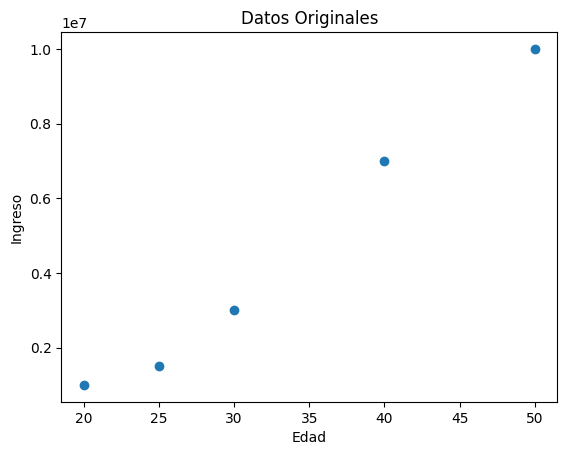

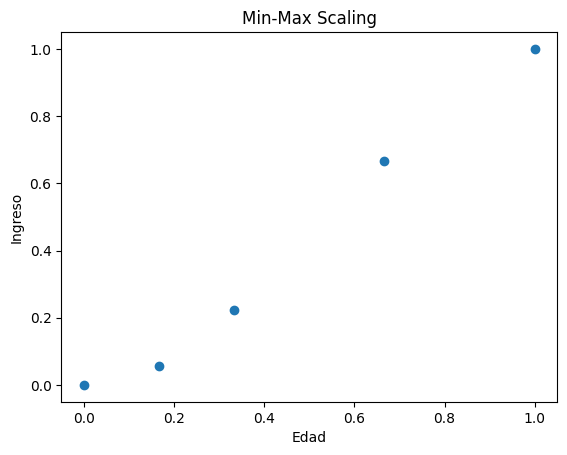

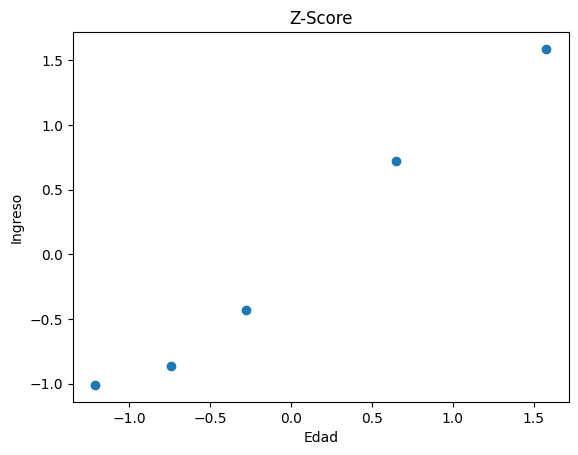

In [51]:
# =========================================
# 🧪 PARTE 5: VISUALIZACIÓN
# =========================================

#“Comparar cómo cambian los datos antes y después de aplicar transformaciones”

import matplotlib.pyplot as plt

# Datos originales
plt.scatter(data['edad'], data['ingreso'])
plt.title("Datos Originales")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()

# MinMax
plt.scatter(minmax_df['edad'], minmax_df['ingreso'])
plt.title("Min-Max Scaling")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()

# Z-score
plt.scatter(zscore_df['edad'], zscore_df['ingreso'])
plt.title("Z-Score")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()


In [52]:
# =========================================
# PARTE 6: ACTIVIDAD
# =========================================

# Ejercicio 1:
# Cambia los valores de ingreso agregando un valor extremo (outlier)
# Ejemplo: 50000000

# Pregunta:
# ¿Qué pasa con Min-Max?
# ¿Qué pasa con Z-score?

# =========================================
# Responde: Escribe las conclusiones


In [53]:
# =========================================
# Ejercicio 2:
# Elimina la columna ingreso y prueba solo con edad

# Pregunta:
# ¿Tiene sentido escalar una sola variable?

# =========================================
# Responde: Escribe las conclusiones


In [54]:
# =========================================
# Ejercicio 3:
# Crea una nueva variable llamada "gasto" y aplica ambas transformaciones

# Pregunta:
# ¿Cuál método funciona mejor?

# =========================================
# Responde: Escribe las conclusiones


In [55]:
# =========================================
# CONCLUSIÓN
# =========================================

# Min-Max:
# ✔ Útil cuando no hay outliers

# Z-Score:
# ✔ Mejor cuando hay valores extremos

# IDEA CLAVE:
# La transformación depende del tipo de datos

# Creando la primer APP Web de Transformación

In [56]:
#PASO 0
!pip install streamlit pyngrok

In [57]:
#PASO 1
%%writefile app.py
# =========================================
# 🚀 APP STREAMLIT: ESCALAMIENTO INTERACTIVO
# =========================================
# Ejecutar con:
# streamlit run app.py

import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

st.title("Escalamiento de Datos Interactivo")

# Crear dataset simple
st.sidebar.header("Configuración de datos")
n = st.sidebar.slider("Número de datos", 5, 100, 20)

np.random.seed(42)
data = pd.DataFrame({
    'edad': np.random.randint(18, 60, n),
    'ingreso': np.random.randint(1000000, 10000000, n)
})

st.subheader("📊 Datos originales")
st.write(data)

# Selección de transformación
option = st.selectbox("Selecciona transformación:", ["Min-Max", "Z-Score"])

if option == "Min-Max":
    scaler = MinMaxScaler()
    transformed = scaler.fit_transform(data)
    st.success("Aplicando Min-Max Scaling")
else:
    scaler = StandardScaler()
    transformed = scaler.fit_transform(data)
    st.success("Aplicando Z-Score")

transformed_df = pd.DataFrame(transformed, columns=data.columns)

st.subheader("📈 Datos transformados")
st.write(transformed_df)

# Visualización
fig, ax = plt.subplots()
ax.scatter(transformed_df['edad'], transformed_df['ingreso'])
ax.set_title("Visualización de datos transformados")
st.pyplot(fig)


# Visualización 2
plt.scatter(data['edad'], data['ingreso'])
plt.title("Datos originales")
plt.show()

st.write("\n🎯 Fin del laboratorio interactivo")


Overwriting app.py


In [58]:
#PASO 2
!streamlit run app.py &>/dev/null &

In [59]:
#PASO 3
!lsof -i:8501

COMMAND    PID USER   FD   TYPE DEVICE SIZE/OFF NODE NAME
streamlit 6381 root   13u  IPv4 186324      0t0  TCP *:8501 (LISTEN)
streamlit 6381 root   14u  IPv6 186325      0t0  TCP *:8501 (LISTEN)


In [60]:
#PASO 4
#Previamente se debe crear una cuenta en ngrok: https://dashboard.ngrok.com/login
from pyngrok import ngrok

ngrok.set_auth_token("3BcwgLbrZDtN4eVIVLPHbHzHaMS_5GkLtmm5zy11ipBVVp9nE")

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://jannie-venereal-unsectionally.ngrok-free.dev" -> "http://localhost:8501"


In [61]:
#PASO 5 - VALIDACIÓN DE DESPLIEGUE
!curl http://localhost:8501

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" />
    <link
      rel="preload"
      href="./static/media/SourceSansVF-Upright.ttf.BsWL4Kly.woff2"
      as="font"
      type="font/woff2"
      crossorig

In [62]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Dataset original con un outlier en ingreso
data_with_outlier = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 50000000] # Outlier añadido
})

print("\n📊 Datos originales con outlier:\n")
print(data_with_outlier)

# Min-Max Scaling con outlier
scaler_minmax = MinMaxScaler()
minmax_data_outlier = scaler_minmax.fit_transform(data_with_outlier)
minmax_df_outlier = pd.DataFrame(minmax_data_outlier, columns=data_with_outlier.columns)

print("\n🔹 Datos con Min-Max Scaling (con outlier):\n")
print(minmax_df_outlier)

# Z-Score con outlier
scaler_zscore = StandardScaler()
zscore_data_outlier = scaler_zscore.fit_transform(data_with_outlier)
zscore_df_outlier = pd.DataFrame(zscore_data_outlier, columns=data_with_outlier.columns)

print("\n🔹 Datos con Z-Score (con outlier):\n")
print(zscore_df_outlier)

# Conclusiones para Ejercicio 1
print("\nConclusiones Ejercicio 1:")
print("¿Qué pasa con Min-Max? El Min-Max Scaling comprime la mayoría de los datos 'normales' en un rango muy pequeño (cerca de 0) cuando hay un outlier extremo, ya que el outlier define el nuevo máximo. Esto reduce la variabilidad entre los otros puntos.\n")
print("¿Qué pasa con Z-score? El Z-Score también se ve afectado por el outlier, resultando en un valor estandarizado muy alto para el outlier y valores más cercanos a cero para los demás. Sin embargo, a diferencia de Min-Max, el Z-Score no 'aplasta' los valores no extremos tan drásticamente hacia un extremo del rango, manteniendo mejor su distribución relativa (aunque la escala cambia por el aumento de la desviación estándar).\n")


📊 Datos originales con outlier:

   edad   ingreso
0    20   1000000
1    25   1500000
2    30   3000000
3    40   7000000
4    50  50000000

🔹 Datos con Min-Max Scaling (con outlier):

       edad   ingreso
0  0.000000  0.000000
1  0.166667  0.010204
2  0.333333  0.040816
3  0.666667  0.122449
4  1.000000  1.000000

🔹 Datos con Z-Score (con outlier):

       edad   ingreso
0 -1.207020 -0.609499
1 -0.742781 -0.582999
2 -0.278543 -0.503499
3  0.649934 -0.291499
4  1.578410  1.987496

Conclusiones Ejercicio 1:
¿Qué pasa con Min-Max? El Min-Max Scaling comprime la mayoría de los datos 'normales' en un rango muy pequeño (cerca de 0) cuando hay un outlier extremo, ya que el outlier define el nuevo máximo. Esto reduce la variabilidad entre los otros puntos.

¿Qué pasa con Z-score? El Z-Score también se ve afectado por el outlier, resultando en un valor estandarizado muy alto para el outlier y valores más cercanos a cero para los demás. Sin embargo, a diferencia de Min-Max, el Z-Score no 'ap

### Ejercicio 2: Escalando una sola variable

### Ejercicio 1: Impacto de un Outlier

In [63]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Dataset original con un outlier en ingreso
data_with_outlier = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 50000000] # Outlier añadido
})

print("\n📊 Datos originales con outlier:\n")
print(data_with_outlier)

# Min-Max Scaling con outlier
scaler_minmax = MinMaxScaler()
minmax_data_outlier = scaler_minmax.fit_transform(data_with_outlier)
minmax_df_outlier = pd.DataFrame(minmax_data_outlier, columns=data_with_outlier.columns)

print("\n🔹 Datos con Min-Max Scaling (con outlier):\n")
print(minmax_df_outlier)

# Z-Score con outlier
scaler_zscore = StandardScaler()
zscore_data_outlier = scaler_zscore.fit_transform(data_with_outlier)
zscore_df_outlier = pd.DataFrame(zscore_data_outlier, columns=data_with_outlier.columns)

print("\n🔹 Datos con Z-Score (con outlier):\n")
print(zscore_df_outlier)


📊 Datos originales con outlier:

   edad   ingreso
0    20   1000000
1    25   1500000
2    30   3000000
3    40   7000000
4    50  50000000

🔹 Datos con Min-Max Scaling (con outlier):

       edad   ingreso
0  0.000000  0.000000
1  0.166667  0.010204
2  0.333333  0.040816
3  0.666667  0.122449
4  1.000000  1.000000

🔹 Datos con Z-Score (con outlier):

       edad   ingreso
0 -1.207020 -0.609499
1 -0.742781 -0.582999
2 -0.278543 -0.503499
3  0.649934 -0.291499
4  1.578410  1.987496


**Conclusiones Ejercicio 1:**

*   **¿Qué pasa con Min-Max?** El Min-Max Scaling comprime la mayoría de los datos 'normales' en un rango muy pequeño (cerca de 0) cuando hay un outlier extremo, ya que el outlier define el nuevo máximo. Esto reduce la variabilidad entre los otros puntos.

*   **¿Qué pasa con Z-score?** El Z-Score también se ve afectado por el outlier, resultando en un valor estandarizado muy alto para el outlier y valores más cercanos a cero para los demás. Sin embargo, a diferencia de Min-Max, el Z-Score no 'aplasta' los valores no extremos tan drásticamente hacia un extremo del rango, manteniendo mejor su distribución relativa (aunque la escala cambia por el aumento de la desviación estándar).

### Ejercicio 2: Escalando una sola variable

In [64]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Usamos el dataset original
data_edad_only = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50]
})

print("\n📊 Datos originales (solo edad):\n")
print(data_edad_only)

# Min-Max Scaling solo con edad
scaler_minmax_edad = MinMaxScaler()
minmax_edad = scaler_minmax_edad.fit_transform(data_edad_only)
minmax_edad_df = pd.DataFrame(minmax_edad, columns=data_edad_only.columns)

print("\n🔹 Datos con Min-Max Scaling (solo edad):\n")
print(minmax_edad_df)

# Z-Score solo con edad
scaler_zscore_edad = StandardScaler()
zscore_edad = scaler_zscore_edad.fit_transform(data_edad_only)
zscore_edad_df = pd.DataFrame(zscore_edad, columns=data_edad_only.columns)

print("\n🔹 Datos con Z-Score (solo edad):\n")
print(zscore_edad_df)


📊 Datos originales (solo edad):

   edad
0    20
1    25
2    30
3    40
4    50

🔹 Datos con Min-Max Scaling (solo edad):

       edad
0  0.000000
1  0.166667
2  0.333333
3  0.666667
4  1.000000

🔹 Datos con Z-Score (solo edad):

       edad
0 -1.207020
1 -0.742781
2 -0.278543
3  0.649934
4  1.578410


**Conclusiones Ejercicio 2:**

*   **¿Tiene sentido escalar una sola variable?** Sí, tiene sentido escalar una sola variable, especialmente cuando se está preparando esa variable para un modelo que es sensible a la escala de las características (por ejemplo, modelos basados en distancia como SVM o K-NN, o redes neuronales). También puede ser útil para la visualización o para comparar su distribución en un rango estandarizado. Sin embargo, su impacto es más evidente cuando se compara con otras variables en el mismo espacio escalado.

### Ejercicio 3: Nueva variable 'gasto'

In [65]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Dataset original
data_original = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 10000000]
})

# Agregamos la nueva variable 'gasto'
# Supongamos que el gasto es una fracción del ingreso, pero con algo de ruido
data_original['gasto'] = data_original['ingreso'] * np.random.uniform(0.1, 0.3, size=len(data_original))

print("\n📊 Datos originales con 'gasto':\n")
print(data_original)

# Min-Max Scaling para 'gasto'
scaler_minmax_gasto = MinMaxScaler()
minmax_gasto = scaler_minmax_gasto.fit_transform(data_original[['gasto']])
minmax_gasto_df = pd.DataFrame(minmax_gasto, columns=['gasto_minmax'])

print("\n🔹 Datos con Min-Max Scaling (solo gasto):\n")
print(minmax_gasto_df)

# Z-Score para 'gasto'
scaler_zscore_gasto = StandardScaler()
zscore_gasto = scaler_zscore_gasto.fit_transform(data_original[['gasto']])
zscore_gasto_df = pd.DataFrame(zscore_gasto, columns=['gasto_zscore'])

print("\n🔹 Datos con Z-Score (solo gasto):\n")
print(zscore_gasto_df)


📊 Datos originales con 'gasto':

   edad   ingreso         gasto
0    20   1000000  2.223239e+05
1    25   1500000  2.386088e+05
2    30   3000000  3.831348e+05
3    40   7000000  1.283003e+06
4    50  10000000  2.983053e+06

🔹 Datos con Min-Max Scaling (solo gasto):

   gasto_minmax
0      0.000000
1      0.005899
2      0.058249
3      0.384203
4      1.000000

🔹 Datos con Z-Score (solo gasto):

   gasto_zscore
0     -0.757326
1     -0.741904
2     -0.605036
3      0.247150
4      1.857117


**Conclusiones Ejercicio 3:**

*   **¿Cuál método funciona mejor?** La elección entre Min-Max y Z-Score depende de la distribución de los datos y de la sensibilidad del modelo a los outliers. Si 'gasto' tiene una distribución relativamente uniforme o acotada y no se esperan outliers extremos, Min-Max puede ser adecuado. Si 'gasto' puede tener outliers o tiene una distribución cercana a la normal, Z-Score es generalmente más robusto, ya que mantiene la forma de la distribución y maneja mejor los valores extremos al no acotar los datos a un rango fijo. Sin conocer la distribución real y el contexto del modelo, es difícil decir cuál funciona 'mejor' universalmente para 'gasto', pero Z-Score suele ser una opción segura cuando se desconoce la distribución o se esperan outliers.

#Conclusiones Generales de todos los ejercicios

**Conclusiones Ejercicio 1:**

*   **¿Qué pasa con Min-Max?** El Min-Max Scaling comprime la mayoría de los datos 'normales' en un rango muy pequeño (cerca de 0) cuando hay un outlier extremo, ya que el outlier define el nuevo máximo. Esto reduce la variabilidad entre los otros puntos.

*   **¿Qué pasa con Z-score?** El Z-Score también se ve afectado por el outlier, resultando en un valor estandarizado muy alto para el outlier y valores más cercanos a cero para los demás. Sin embargo, a diferencia de Min-Max, el Z-Score no 'aplasta' los valores no extremos tan drásticamente hacia un extremo del rango, manteniendo mejor su distribución relativa (aunque la escala cambia por el aumento de la desviación estándar).

**Ejercicio 2: Escalando una sola variable**

**Conclusiones Ejercicio 2:**

*   **¿Tiene sentido escalar una sola variable?** Sí, tiene sentido escalar una sola variable, especialmente cuando se está preparando esa variable para un modelo que es sensible a la escala de las características (por ejemplo, modelos basados en distancia como SVM o K-NN, o redes neuronales). También puede ser útil para la visualización o para comparar su distribución en un rango estandarizado. Sin embargo, su impacto es más evidente cuando se compara con otras variables en el mismo espacio escalado.

**Ejercicio 3: Nueva variable 'gasto'**

**Conclusiones Ejercicio 3:**

*   **¿Cuál método funciona mejor?** La elección entre Min-Max y Z-Score depende de la distribución de los datos y de la sensibilidad del modelo a los outliers. Si 'gasto' tiene una distribución relativamente uniforme o acotada y no se esperan outliers extremos, Min-Max puede ser adecuado. Si 'gasto' puede tener outliers o tiene una distribución cercana a la normal, Z-Score es generalmente más robusto, ya que mantiene la forma de la distribución y maneja mejor los valores extremos al no acotar los datos a un rango fijo. Sin conocer la distribución real y el contexto del modelo, es difícil decir cuál funciona 'mejor' universalmente para 'gasto', pero Z-Score suele ser una opción segura cuando se desconoce la distribución o se esperan outliers.